## Accesing API Key 

Install and import anthropic library

In [1]:
#!pip install anthropic
from anthropic import HUMAN_PROMPT, AI_PROMPT
import anthropic
import os
from dotenv import load_dotenv

Load the env file and get API key running

In [2]:
load_dotenv()
api_key = os.getenv("ANTHROPIC_API_KEY")

class LLM():
    def __init__(self, api_key = api_key, model = "claude-3-5-sonnet-20240620"):
        self.client = anthropic.Anthropic(api_key = api_key)
        self.model = model

    def generate(self, prompt, max_tokens=1024):
        response = self.client.messages.create(
        model=self.model,
        max_tokens=max_tokens,
        messages=[
            {"role": "user", "content": prompt}
            ]
        )
        # Extract only the response, no other info 
        return response.content[0].text.strip()

testing the api 

In [3]:
claude_example = LLM()
print(claude_example.generate("Hello, Claude"))

Hello! It's nice to meet you. How can I assist you today?


### Understanding Tone Identification 
**Tone Identification**  involves determining the tone of a given piece of text. This code will start by using sample text to evaluate how Anthropic's Claude identifies tone and compare its predictions to the ground truth to calculate an accuracy score. The accuracy score will then be compared to results from other evaluation frameworks that use packages designed to assess tone, allowing us to gauge how well each framework performs.

 **Using Sample Text Data:**

create a mini file with sample data - this is preliminary to test how claude works and get a better understanding of the processes without using a large dataset: 

In [4]:
#import pandas 
import pandas as pd

In [5]:
#create sample data 
data = {
    "Text": [
        "I am so happy to see you!",
        "This is the worst day ever!",
        "I'm feeling okay",
        "You make me so upset when you do that.",
        "What a wonderful surprise!",
        "I'm disappointed with the results.",
        "Everything is going just as planned!",
        "Lets do this next instead.",
        "This is absolutely fantastic!",
        "I feel okay about this topic."
    ],
    "Label": [
        "happy",
        "angry",
        "neutral",
        "angry",
        "happy",
        "sad",
        "happy",
        "neutral",
        "happy",
        "neutral"
    ]
}

# Convert the data into a DataFrame and only get text 
sample_data = pd.DataFrame(data)

now using this sample data we will feed it to claude to see what responses for tone it generates: 

In [6]:
# Define a function to query the API for tone analysis
def get_tone_claude(text):
    prompt = (
        f"What is the tone of this text? '{text}'\n"
        "Please choose only one tone from the following options: happy, angry, sad, or neutral."
        "Respond only with the tone (e.g., 'happy')."
    )
    return claude_example.generate(prompt)

In [7]:
#Apply the function to the dataset and store the results
sample_data["Predicted_Tone"] = sample_data["Text"].apply(get_tone_claude)

In [8]:
#view sample data
sample_data

,Text,Label,Predicted_Tone
0,I am so happy to see you!,happy,happy
1,This is the worst day ever!,angry,angry
2,I'm feeling okay,neutral,neutral
3,You make me so upset when you do that.,angry,angry
4,What a wonderful surprise!,happy,happy
5,I'm disappointed with the results.,sad,sad
6,Everything is going just as planned!,happy,happy
7,Lets do this next instead.,neutral,neutral
8,This is absolutely fantastic!,happy,happy
9,I feel okay about this topic.,neutral,neutral


# Assesing Tone Identification Using VADER
## Step 1: Prepare Your Dataset
Downloaded hugging face sentiment dataset with 5000 single line text and their corresponding sentiment 

In [11]:
tone_dataset = pd.read_csv("/Users/dishatrivedi/Library/CloudStorage/OneDrive-Personal/UVA Graduate College/Capstone/LLM-eval-framework-comparison/notebooks/hugging_dataset.csv")
tone_dataset.head()

,id,text,label,sentiment
0,9235,getting cds ready for tour,1,neutral
1,16790,"MC, happy mother`s day to your mom ;).. love yah",2,positive
2,24840,A year from now is graduation....i am pretty s...,0,negative
3,20744,because you had chips and sale w/o me,1,neutral
4,6414,Great for organising my work life balance,2,positive


In [20]:
tone_dataset = tone_dataset[tone_dataset["text"].apply(lambda x: isinstance(x, str))]
tone_dataset['text']

0                              getting cds ready for tour
1        MC, happy mother`s day to your mom ;).. love yah
2       A year from now is graduation....i am pretty s...
3                   because you had chips and sale w/o me
4               Great for organising my work life balance
                              ...                        
5201                   Fuck no internet damn time warner!
5202     Looking forward to android 1.5 being pushed t...
5203                               Not good. Wasted time.
5204     U were great, as always. But, can`t we do an ...
5205     - Love your desserts. Used to live in OR but ...
Name: text, Length: 5205, dtype: object

## Step 2: Setup

In [12]:
!pip install vaderSentiment


In [13]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

## Step 2: Using the Analzer

In [21]:
def get_vader_sentiment(text):
    """Analyze sentiment using VADER and return both compound score and sentiment classification."""
    sentiment_scores = analyzer.polarity_scores(text)
    compound_score = sentiment_scores["compound"]

    # Classify based on compound score
    if compound_score >= 0.05:
        sentiment_label = "Positive"
    elif compound_score <= -0.05:
        sentiment_label = "Negative"
    else:
        sentiment_label = "Neutral"

    return compound_score, sentiment_label

# Apply VADER analysis only to the "Text" column
tone_dataset[["VADER_Compound_Score", "VADER_Predicted"]] = tone_dataset["text"].apply(get_vader_sentiment).apply(pd.Series)

In [22]:
tone_dataset[["text", "sentiment", "VADER_Predicted", "VADER_Compound_Score"]].head()

,text,sentiment,VADER_Predicted,VADER_Compound_Score
0,getting cds ready for tour,neutral,Positive,0.3612
1,"MC, happy mother`s day to your mom ;).. love yah",positive,Positive,0.8360
2,A year from now is graduation....i am pretty s...,negative,Positive,0.7009
3,because you had chips and sale w/o me,neutral,Neutral,0.0000
4,Great for organising my work life balance,positive,Positive,0.6249


In [27]:
tone_dataset["VADER_Predicted"] = tone_dataset["VADER_Predicted"].astype(str).str.lower()

In [29]:
len(tone_dataset)

5205

In [28]:
#filter out those that are correct 
correct_VADER = tone_dataset[tone_dataset["sentiment"] == tone_dataset['VADER_Predicted']]

#groupby tone to see number predicted and average confidence of prediction 
correct_VADER.groupby('sentiment').agg({'VADER_Predicted' : 'count', 'VADER_Compound_Score' : 'mean'} )

,VADER_Predicted,VADER_Compound_Score
sentiment,,
negative,872,-0.478768
neutral,769,0.000633
positive,1515,0.669046


Overall Accuracy is 60.63%

# Anthropic LLM Performance - LLM as Judge 

In [30]:
# Define a function to query the API for tone analysis - simple tone 
def get_tone_claude(text):
    prompt = (
        f"What is the tone of this text? '{text}'\n"
        "Please choose only one tone from the following options: negative, neutral, or positive."
        "Respond only with the tone (e.g., 'neutral')."
    )
    return claude_example.generate(prompt)

In [ ]:
tone_dataset.loc[:99, "LLM Basic Tone"] = tone_dataset.loc[:99, "text"].apply(get_tone_claude)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x104a08e30>>
Traceback (most recent call last):
  File "/Users/dishatrivedi/miniconda3/envs/data_science_env/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [33]:
tone_dataset[['text', 'sentiment', 'LLM Basic Tone']]

,text,sentiment,LLM Basic Tone
0,getting cds ready for tour,neutral,neutral
1,"MC, happy mother`s day to your mom ;).. love yah",positive,Positive
2,A year from now is graduation....i am pretty s...,negative,negative
3,because you had chips and sale w/o me,neutral,negative
4,Great for organising my work life balance,positive,positive
...,...,...,...
5201,Fuck no internet damn time warner!,negative,NaN
5202,Looking forward to android 1.5 being pushed t...,neutral,NaN
5203,Not good. Wasted time.,negative,NaN
5204,"U were great, as always. But, can`t we do an ...",positive,NaN


In [34]:
# Set chunk size and total number of rows
chunk_size = 100
total_rows = len(tone_dataset)

# If the column doesn't exist yet, create it with empty values
if "LLM Basic Tone" not in tone_dataset.columns:
    tone_dataset["LLM Basic Tone"] = None

# Loop through in chunks of 100
for start in range(0, total_rows, chunk_size):
    end = min(start + chunk_size, total_rows)
    
    print(f"Processing rows {start} to {end-1}...")

    # Only apply to rows that haven't already been processed
    mask = tone_dataset.loc[start:end-1, "LLM Basic Tone"].isnull()
    rows_to_process = tone_dataset.loc[start:end-1].loc[mask]

    if not rows_to_process.empty:
        tone_dataset.loc[rows_to_process.index, "LLM Basic Tone"] = rows_to_process["text"].apply(get_tone_claude)


Processing rows 0 to 99...
Processing rows 100 to 199...
Processing rows 200 to 299...
Processing rows 300 to 399...
Processing rows 400 to 499...
Processing rows 500 to 599...
Processing rows 600 to 699...
Processing rows 700 to 799...
Processing rows 800 to 899...
Processing rows 900 to 999...
Processing rows 1000 to 1099...
Processing rows 1100 to 1199...
Processing rows 1200 to 1299...
Processing rows 1300 to 1399...
Processing rows 1400 to 1499...
Processing rows 1500 to 1599...
Processing rows 1600 to 1699...
Processing rows 1700 to 1799...
Processing rows 1800 to 1899...
Processing rows 1900 to 1999...
Processing rows 2000 to 2099...
Processing rows 2100 to 2199...
Processing rows 2200 to 2299...
Processing rows 2300 to 2399...
Processing rows 2400 to 2499...
Processing rows 2500 to 2599...
Processing rows 2600 to 2699...
Processing rows 2700 to 2799...
Processing rows 2800 to 2899...
Processing rows 2900 to 2999...
Processing rows 3000 to 3099...
Processing rows 3100 to 3199...

In [35]:
tone_dataset

,id,text,label,sentiment,VADER_Compound_Score,VADER_Predicted,LLM Basic Tone
0,9235,getting cds ready for tour,1,neutral,0.3612,positive,neutral
1,16790,"MC, happy mother`s day to your mom ;).. love yah",2,positive,0.8360,positive,Positive
2,24840,A year from now is graduation....i am pretty s...,0,negative,0.7009,positive,negative
3,20744,because you had chips and sale w/o me,1,neutral,0.0000,neutral,negative
4,6414,Great for organising my work life balance,2,positive,0.6249,positive,positive
...,...,...,...,...,...,...,...
5201,10277,Fuck no internet damn time warner!,0,negative,-0.5767,negative,negative
5202,8610,Looking forward to android 1.5 being pushed t...,1,neutral,0.4824,positive,Positive
5203,8114,Not good. Wasted time.,0,negative,0.0572,positive,negative
5204,3034,"U were great, as always. But, can`t we do an ...",2,positive,-0.8608,negative,Negative


In [39]:
#import to csv 
tone_dataset.to_csv("/Users/dishatrivedi/Library/CloudStorage/OneDrive-Personal/UVA Graduate College/Capstone/LLM-eval-framework-comparison/notebooks/claude_hugging")

In [36]:
#filter dataset to count accuracy 
correct_Claude2 = tone_dataset[tone_dataset["sentiment"].str.lower() == tone_dataset["LLM Basic Tone"].str.lower()]

# Group by tone type to count correct predictions and get insights
claude_results2 = correct_Claude2.groupby("sentiment").agg({
    "LLM Basic Tone": "count"
}).rename(columns={"LLM Basic Tone": "Correct Predictions"})

In [37]:
claude_results2

,Correct Predictions
sentiment,
negative,1119
neutral,857
positive,1402


Claude is 64.90 accurate

# Getting Results

In [38]:
#import packages to do calculations 
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [40]:
#define function to evaluate 
def evaluate_predictions(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    print(f"\n📊 {model_name} Evaluation:")
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")
    print(f"F1 Score : {f1:.2f}")


In [43]:
#evaluate each model 
# Normalize tone labels to lowercase to ensure consistency
tone_dataset['sentiment'] = tone_dataset['sentiment'].str.lower()
tone_dataset['VADER_Predicted'] = tone_dataset['VADER_Predicted'].str.lower()
tone_dataset['LLM Basic Tone'] = tone_dataset['LLM Basic Tone'].str.lower()
tone_dataset = tone_dataset.dropna(subset=['LLM Basic Tone'])


# Run evaluation
evaluate_predictions(tone_dataset['sentiment'], tone_dataset['VADER_Predicted'], "VADER")
evaluate_predictions(tone_dataset['sentiment'], tone_dataset['LLM Basic Tone'], "Claude (LLM)")


📊 VADER Evaluation:
Accuracy : 0.61
Precision: 0.63
Recall   : 0.61
F1 Score : 0.59

📊 Claude (LLM) Evaluation:
Accuracy : 0.65
Precision: 0.65
Recall   : 0.65
F1 Score : 0.64


# Plotting 

## VADER vs. Claude

In [ ]:
# Prepare VADER vs. Claude data
vader_results = tone_dataset[tone_dataset["sentiment"].str.lower() == tone_dataset["VADER_Predicted"].str.lower()]
claude_results = tone_dataset[tone_dataset["sentiment"].str.lower() == tone_dataset["LLM Basic Tone"].str.lower()]


In [95]:
# Count correct predictions per sentiment
vader_counts = vader_results["Overall Tone"].value_counts()
claude_counts = claude_results["Overall Tone"].value_counts()


In [96]:
# Ensure consistent order for sentiments
sentiments = ["Negative", "Neutral", "Positive"]
vader_correct = [vader_counts.get(sentiment, 0) for sentiment in sentiments]
claude_correct = [claude_counts.get(sentiment, 0) for sentiment in sentiments]

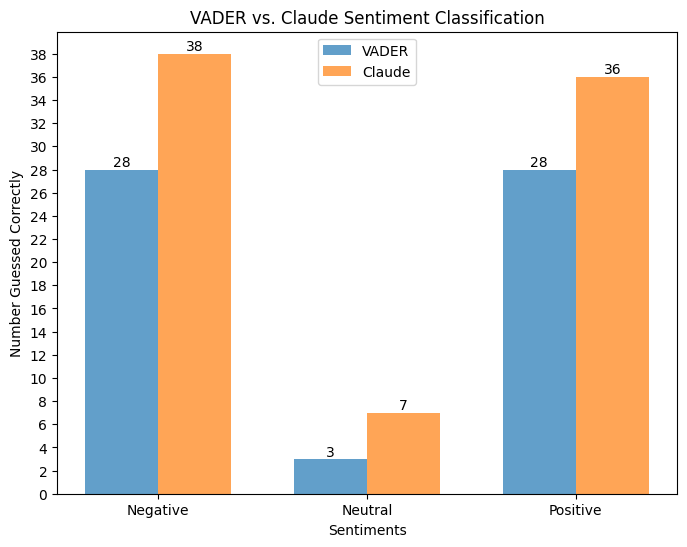

In [98]:
# Plot
x = np.arange(len(sentiments))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, vader_correct, width, label="VADER", alpha=0.7)
bars2 = ax.bar(x + width/2, claude_correct, width, label="Claude", alpha=0.7)

# Add number labels on top of bars
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

# Set whole number y-ticks at intervals of 2
max_y = max(max(vader_correct, default=0), max(claude_correct, default=0))
ax.set_yticks(range(0, max_y + 2, 2))  # Adjust step size if needed

ax.set_xlabel("Sentiments")
ax.set_ylabel("Number Guessed Correctly")
ax.set_title("VADER vs. Claude Sentiment Classification")
ax.set_xticks(x)
ax.set_xticklabels(sentiments)
ax.legend()

plt.show()

In [100]:
tone_dataset["Overall Tone"].value_counts()

Overall Tone
Negative     39
Positive     36
Neutral      22
Negative      2
Name: count, dtype: int64